In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [130]:
import netCDF4
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import time
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
from scipy.spatial import Delaunay
from joblib import Parallel, delayed
from matplotlib.colors import ListedColormap
from scipy.io import loadmat
from matplotlib.text import Text
from skimage.segmentation import find_boundaries

In [165]:

cA.shape

(260, 1000)

In [4]:
colormap_data = loadmat('cold2hot.mat')
cold2hot = ListedColormap(colormap_data['colormap'])
hot2cold = ListedColormap(colormap_data['colormap'][::-1])

In [ ]:
420W045mps

In [19]:
power_level = "420"
scanspeed = "045"
ScanSpeed = 45

In [6]:
numpy_path = os.path.abspath(f'../../1_Simulation_Results/{power_level}W{scanspeed}mps/')

In [ ]:
t_step = 500

In [114]:
cA = np.load(numpy_path+'/cA.npy')[t_step]
cB = np.load(numpy_path+'/cB.npy')[t_step]
cC = np.load(numpy_path+'/cC.npy')[t_step]
cD = np.load(numpy_path+'/cD.npy')[t_step]
Temp = np.load(numpy_path+'/TEMP.npy')[t_step]
TIME = np.load(numpy_path+'/time.npy')

In [117]:
cA.max(), cA.min(), cB.max(), cB.min(), cC.max(), cC.min(), cD.max(), cD.min(), 

(0.36, 0.24, 0.19, 0.13, 0.26, 0.14, 0.37, 0.31)

In [118]:
cB[:, :300] = 0.18
cD[:, :300] = 0.32

In [115]:
laser_speed = 45
time = TIME[t_step]
laser_pos = 125 + (time-3)*(ScanSpeed*1e-2)

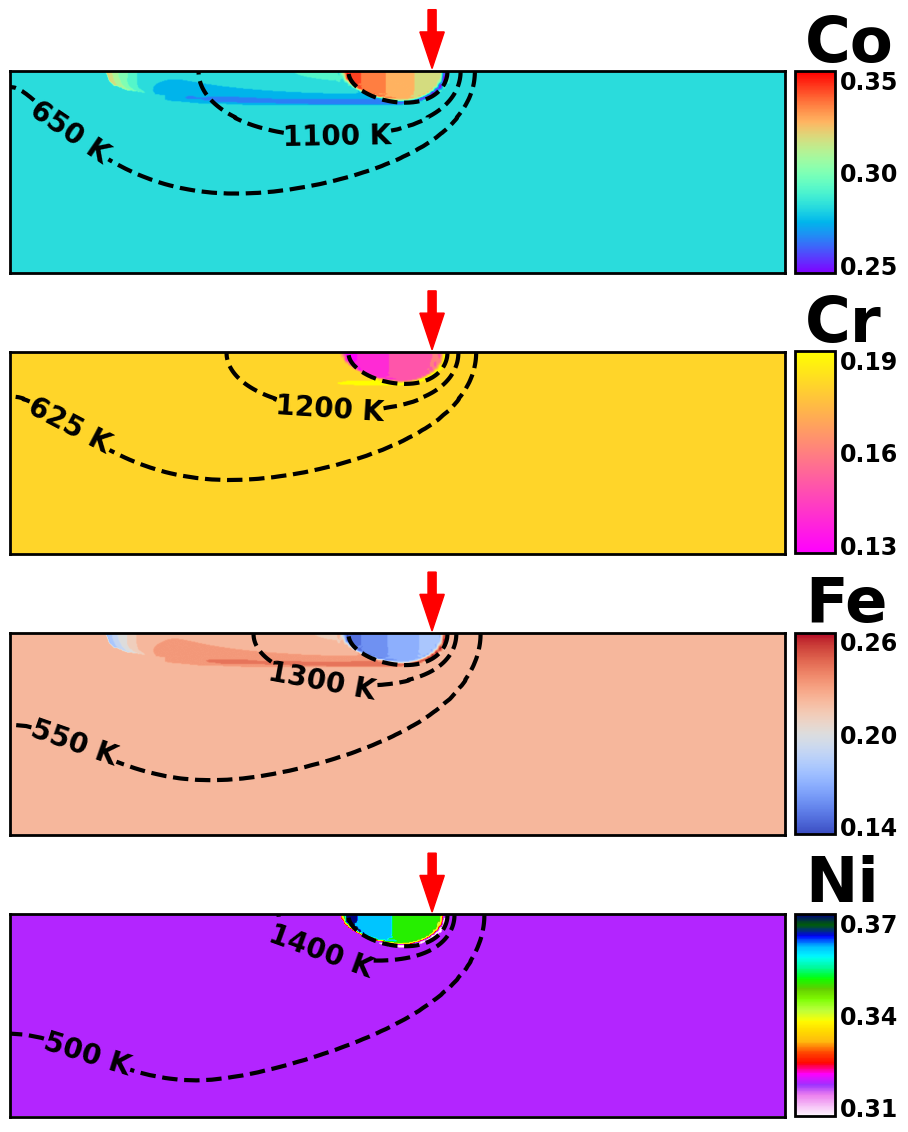

In [168]:
fig, ((ax1, ax2, ax3, ax4)) = plt.subplots(4, 1, figsize=[10, 14], frameon=False)
ax1.set_facecolor((0, 0, 0, 0))

vmin = 0.0
vmax=1.0

ax1.arrow(laser_pos, -80, 0, 76,  width = 10.5, color='red', length_includes_head=True, clip_on=False)
cmap = plt.get_cmap('rainbow')
cmap.set_under('white', alpha=0)
hmap1a = ax1.imshow(cA, cmap=cmap,  aspect=1.0,  interpolation='quadric')
contour_levels = [650, 1100, 1800]
label_colors = ['k', 'k', 'k']
contour = ax1.contour(Temp, levels=contour_levels, colors='black', linewidths=3, linestyles='dashed')
labels = plt.clabel(contour, inline=True, fontsize=20, fmt='%1.0f K')
for label, color in zip(labels, label_colors): label.set_fontweight('bold');label.set_color(color) 


ax2.arrow(laser_pos, -80, 0, 76,  width = 10.5, color='red', length_includes_head=True, clip_on=False)
cmap = plt.get_cmap('spring')
cmap.set_under('white', alpha=0)
hmap2a = ax2.imshow(cB, cmap=cmap,  aspect=1.0,  interpolation='quadric')
contour_levels = [625, 1200, 1800]
label_colors = ['k', 'k', 'k']
contour = ax2.contour(Temp, levels=contour_levels, colors='black', linewidths=3, linestyles='dashed')
labels = plt.clabel(contour, inline=True, fontsize=20, fmt='%1.0f K')
for label, color in zip(labels, label_colors): label.set_fontweight('bold');label.set_color(color) 


ax3.arrow(laser_pos, -80, 0, 76,  width = 10.5, color='red', length_includes_head=True, clip_on=False)
cmap = plt.get_cmap('coolwarm')
cmap.set_under('white', alpha=0)
hmap3a = ax3.imshow(cC, cmap=cmap,  aspect=1.0,  interpolation='quadric')
contour_levels = [550, 1300, 1800]
label_colors = ['k', 'k', 'k']
contour = ax3.contour(Temp, levels=contour_levels, colors='black', linewidths=3, linestyles='dashed')
labels = plt.clabel(contour, inline=True, fontsize=20, fmt='%1.0f K')
for label, color in zip(labels, label_colors): label.set_fontweight('bold');label.set_color(color) 


ax4.arrow(laser_pos, -80, 0, 76,  width = 10.5, color='red', length_includes_head=True, clip_on=False)
cmap = plt.get_cmap('gist_ncar_r')
cmap.set_under('white', alpha=0)
hmap4a = ax4.imshow(cD, cmap=cmap,  aspect=1.0,  interpolation='quadric')
contour_levels = [500, 1400, 1800]
label_colors = ['k', 'k', 'k']
contour = ax4.contour(Temp, levels=contour_levels, colors='black', linewidths=3, linestyles='dashed')
labels = plt.clabel(contour, inline=True, fontsize=20, fmt='%1.0f K')
for label, color in zip(labels, label_colors): label.set_fontweight('bold');label.set_color(color) 




ax1.tick_params(axis='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax2.tick_params(axis='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax3.tick_params(axis='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax4.tick_params(axis='both', bottom=False, left=False, labelbottom=False, labelleft=False)

ax1a = fig.add_axes([0.91, 0.724, 0.04, 0.144]) 
cbar = fig.colorbar(hmap1a, cax=ax1a)
cbar.ax.tick_params(labelsize=17,length=0)
cbar.set_ticks([0.245, 0.3, 0.355], labels=['0.25', '0.30', '0.35'], weight='bold') 

ax2a = fig.add_axes([0.91, 0.524, 0.04, 0.144]) 
cbar = fig.colorbar(hmap2a, cax=ax2a)
cbar.ax.tick_params(labelsize=17,length=0)
cbar.set_ticks([0.1325, 0.160, 0.1875], labels=['0.13', '0.16', '0.19'], weight='bold') 

ax3a = fig.add_axes([0.91, 0.323, 0.04, 0.144]) 
cbar = fig.colorbar(hmap3a, cax=ax3a)
cbar.ax.tick_params(labelsize=17,length=0)
cbar.set_ticks([0.145, 0.20, 0.255], labels=['0.14', '0.20', '0.26'], weight='bold') 

ax4a = fig.add_axes([0.91, 0.122, 0.04, 0.144]) 
cbar = fig.colorbar(hmap4a, cax=ax4a)
cbar.ax.tick_params(labelsize=17,length=0)
cbar.set_ticks([0.3125, 0.34, 0.3675], labels=['0.31', '0.34', '0.37'], weight='bold') 


# text1 = Text(x=1.03, y=0.73, text=r'$\mathbf{\leftarrow}$   C$_{\mathbf{Cr}}$ $\mathbf{\rightarrow}$', fontsize=28, color='red', rotation=90, weight='bold')
text1 = Text(x=0.92, y=0.875, text=r'Co', fontsize=45, color='k', rotation=00, weight='bold')
text2 = Text(x=0.92, y=0.675, text=r'Cr', fontsize=45, color='k', rotation=00, weight='bold')
text3 = Text(x=0.92, y=0.475, text=r'Fe', fontsize=45, color='k', rotation=00, weight='bold')
text4 = Text(x=0.92, y=0.275, text=r'Ni', fontsize=45, color='k', rotation=00, weight='bold')
fig.add_artist(text1)
fig.add_artist(text2)
fig.add_artist(text3)
fig.add_artist(text4)

ax1.set_ylim(260, -1);  ax1.set_xlim(-1,1000)
ax2.set_ylim(260, -1);  ax2.set_xlim(-1,1000)
ax3.set_ylim(260, -1);  ax3.set_xlim(-1,1000)
ax4.set_ylim(260, -1);  ax3.set_xlim(-1,1000)
ax1.spines[:].set_linewidth(2)
ax1a.spines[:].set_linewidth(2)
ax2.spines[:].set_linewidth(2)
ax2a.spines[:].set_linewidth(2)
ax3.spines[:].set_linewidth(2)
ax3a.spines[:].set_linewidth(2)
ax4.spines[:].set_linewidth(2)
ax4a.spines[:].set_linewidth(2)

# plt.savefig('420W045mps_1000by260micrometers.png',bbox_inches='tight', dpi=800)
plt.savefig('420W045mps_1000by260micrometers.jpg',bbox_inches='tight', dpi=800)

plt.show()

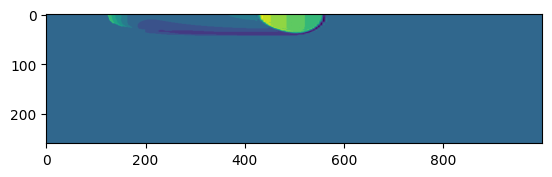

In [10]:
plt.imshow(cA[500])

In [ ]:
laser_pos = 125 + (time-3)*(ScanSpeed*1e-2)

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=[10, 10], frameon=True)
ax1.set_facecolor((0, 0, 0, 0))

t_step = 24
# laser_pos = (125 + (TIME[t_step]-3)*(ScanSpeed*1e-2))  ## 3--> laser moves after 3mus
eta = LIQ[t_step,:,:]
temp = TEMP[t_step,:,:]
vel = np.where(eta > 0.5, VEL[t_step,:,:], 0)
time = TIME[t_step]
laser_pos = 125 + (time-3)*(ScanSpeed*1e-2)

ax1.arrow(laser_pos, -80, 0, 76,  width = 8.5, color='red', length_includes_head=True, clip_on=False)
cmap = plt.get_cmap('RdYlGn_r')
cmap.set_under('white', alpha=0)
hmap1a = ax1.imshow(eta, cmap=cmap, vmin=0.5, vmax=1.0, aspect=1.0,  interpolation='quadric')
cmap = plt.get_cmap('Wistia')
cmap.set_under('white', alpha=0) 
hmap1b = ax1.imshow(1-eta, cmap=cmap, vmin=0.5, vmax=1.5, aspect=1.0, interpolation='quadric')
ax1.contour(temp, levels=[1858], colors='black', linewidths=1, linestyles='dashed')


ax2.arrow(laser_pos, -80, 0, 76,  width = 8.5, color='red', length_includes_head=True, clip_on=False)
hmap2 = ax2.imshow(temp, cmap='rainbow', vmin=300, aspect=1.0,  interpolation='quadric')
ax2.contour(eta, levels=[0.5], colors='red', linewidths=1, linestyles='-')
ax2.contour(temp, levels=[1858], colors='black', linewidths=1, linestyles='dashed')
############## Color Bar ##########
ax2a = fig.add_axes([0.91, 0.395, 0.04, 0.2]) 
cbar = fig.colorbar(hmap2, cax=ax2a)
cbar.ax.tick_params(labelsize=17,length=0)
cbar.set_ticks([np.min(temp)*1.15, (np.max(temp)+300)/2, np.max(temp)*0.97], labels=[f'{np.min(temp):.0f}', f'{(np.max(temp)+300)/2 :.0f}', f'{np.max(temp):.0f}'], weight='bold') 

ax3.arrow(laser_pos, -80, 0, 76,  width = 8.5, color='red', length_includes_head=True, clip_on=False)
hmap3 = ax3.imshow(vel, cmap='gist_ncar_r', aspect=1.0,  interpolation='bilinear')
ax3.contour(eta, levels=[0.5], colors='red', linewidths=1, linestyles='-')
ax3.contour(temp, levels=[1858], colors='black', linewidths=1, linestyles='dashed')
############## Color Bar ##########
ax3a = fig.add_axes([0.91, 0.125, 0.04, 0.2]) 
cbar = fig.colorbar(hmap3, cax=ax3a)
cbar.ax.tick_params(labelsize=17,length=0)
cbar.set_ticks([np.min(vel)*1.15, (np.max(vel)+np.min(vel))/2, np.max(vel)*0.97], labels=[f'{np.min(vel):.2f}', f'{(np.max(vel)+np.min(vel))/2 :.2f}', f'{np.max(vel):.2f}'], weight='bold') 


ax1.tick_params(axis='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax2.tick_params(axis='both', bottom=False, left=False, labelbottom=False, labelleft=False)
ax3.tick_params(axis='both', bottom=False, left=False, labelbottom=False, labelleft=False)

ax1.set_ylim(260, -1);  ax1.set_xlim(-1,1000)
ax2.set_ylim(260, -1);  ax2.set_xlim(-1,1000)
ax3.set_ylim(260, -1);  ax3.set_xlim(-1,1000)
ax1.spines[:].set_linewidth(2)
ax2.spines[:].set_linewidth(2)
ax2a.spines[:].set_linewidth(2)
ax3.spines[:].set_linewidth(2)
plt.show()